In [1]:
import os
import sys

from scipy.stats import multivariate_normal

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Sample dataset
This notebook has the purpose of generating a sample data set for the training of a stochastic network.
Can a PyKAN network really solve a probabilistic regression task?

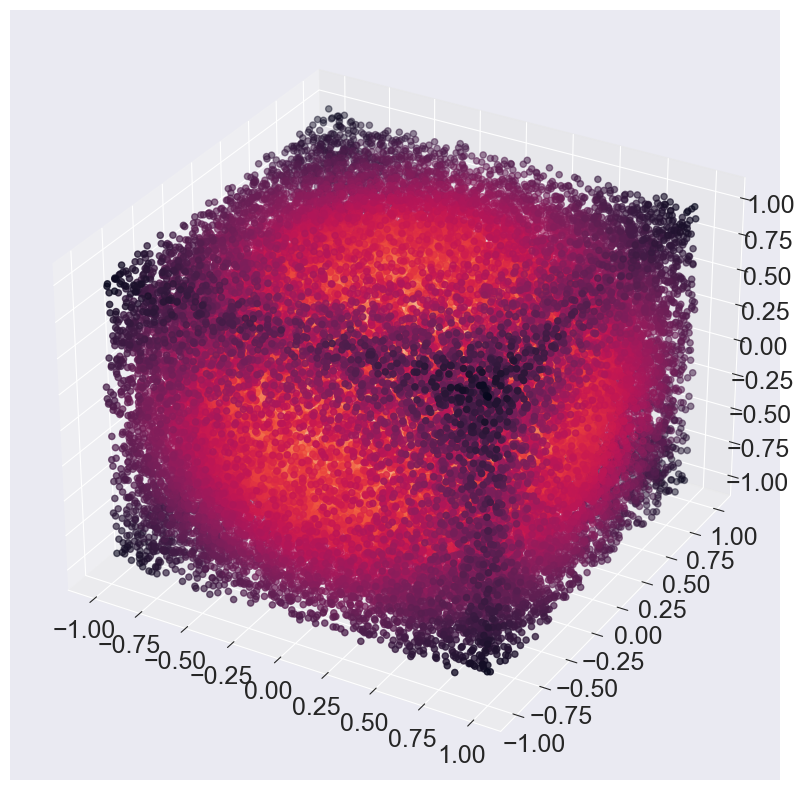

In [2]:
# 2s
SAMPLES = 50_000
np.random.seed(1)

x1 = np.random.uniform(-1, 1, SAMPLES)
x2 = np.random.uniform(-1, 1, SAMPLES)
x3 = np.random.uniform(-1, 1, SAMPLES)

mv_normal = multivariate_normal(mean=np.zeros(3), cov=np.eye(3))
label = mv_normal.pdf(np.column_stack((x1, x2, x3)))
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.scatter(x1, x2, x3, c=label)
df = pd.DataFrame(dict(x1=x1, x2=x2, x3=x3, label=label))
# df.to_csv('../dataset/3d_normal_std.csv', index=False)

## PyKAN Training

In [3]:
pyKAN: PHMNetwork = PyKAN([3, 1, 2], 'regression',device='cpu')

checkpoint directory created: ./model
saving model version 0.0


Time 1/1===========================
checkpoint directory created: ./model
saving model version 0.0


100%|██████████| 2/2 [00:00<00:00, 47.20it/s, epoch=29, loss=-2.2, lr=0.0153]


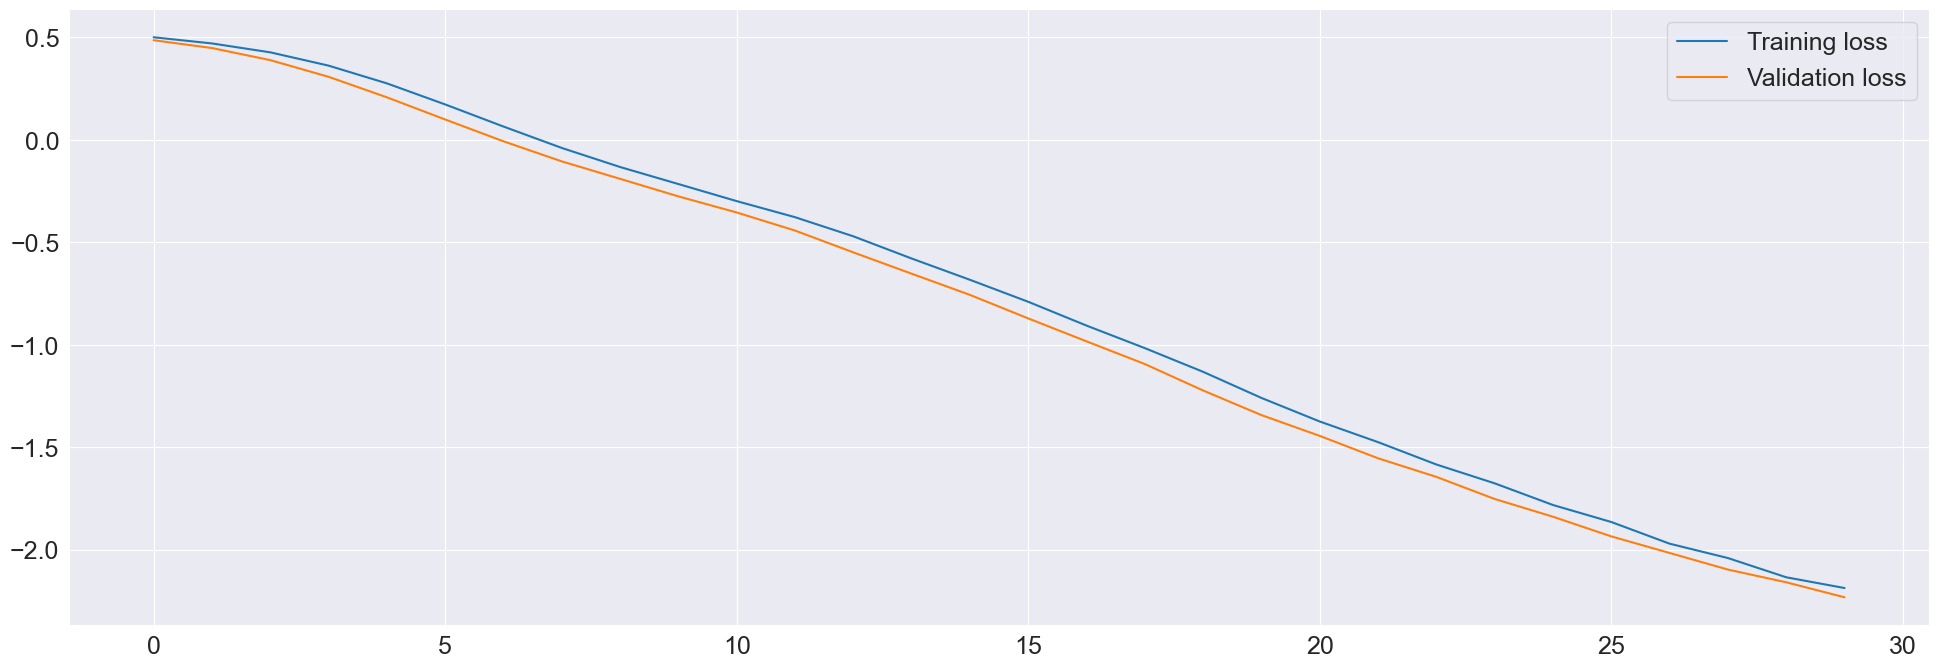

100%|██████████| 3/3 [00:00<00:00, 45.50it/s]


,test_loss
0,-2.230804


In [4]:
# 4s
pyKAN.multi_train(df[['x1', 'x2', 'x3']], df['label'],epochs=30, times=1)

Here comes the high interpretability of KANs

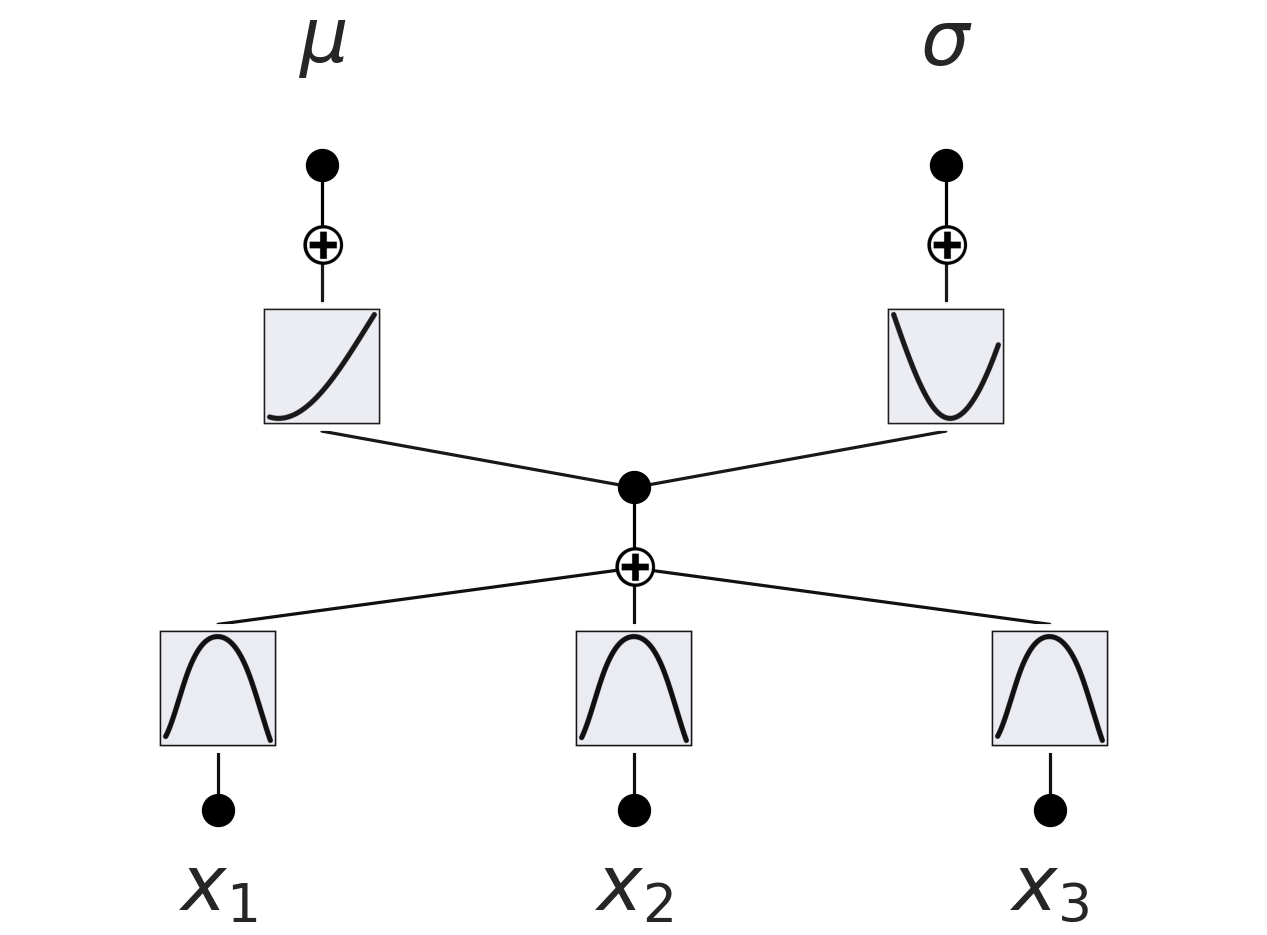

In [5]:
# 1s
pyKAN.plot(scale=0.6, in_vars=[f'$x_{i}$' for i in range(1, 4)])